In [1]:
from sentence_transformers import SentenceTransformer

# initialize of CLIP model
model = SentenceTransformer('clip-ViT-B-32', device='cpu')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: C:\Users\User\.cache\huggingface\hub\models--sentence-transformers--clip-ViT-B-32\snapshots\327ab6726d33c0e22f920c83f2ff9e4bd38ca37f\0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


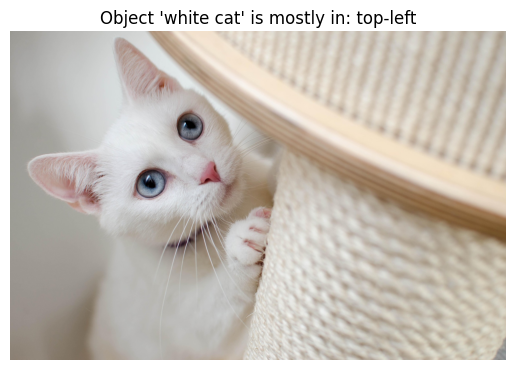

Indexed all images


INFO:     Started server process [14316]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [2]:
import chromadb
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image
from fastapi import FastAPI, UploadFile, File, Response
import io
import nest_asyncio
import uvicorn

# configure chromaDB
client = chromadb.PersistentClient(path="./db")
collection = client.get_or_create_collection(name="image_search")

# create embeddings for all images in folder. After that add them to db.
def index_images(data_path):
    image_paths = list(Path(data_path).glob('*.jpg'))

    for img_path in image_paths:
        image_id = img_path.name

        # check in database
        existing = collection.get(ids=[image_id])
        if len(existing['ids']) > 0:
            continue

        # create embedding from each image
        image = Image.open(img_path)
        embedding = model.encode(image).tolist()

        # add this embedding to database (collection)
        collection.add(
            ids=[image_id],
            embeddings=[embedding],
            metadatas=[{"path": str(img_path)}]
        )

    print("Indexed all images")

def search_images(query_text:str, n_results=1):
    # create embedding of text (use Text Encoder of CLIP)
    query_embedding = model.encode(query_text).tolist()

    # search in db
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=n_results
    )

    formatted_results = []

    for i in range(len(results['ids'][0])):
        formatted_results.append({
            "id": results['ids'][0][i],
            "path": results['metadatas'][0][i]['path'],
            "distance": float(results['distances'][0][i])
        })

    return formatted_results

#if __name__ == "__main__":
    #print("\n Testing")
    #user_query = "white cat"
    #formatted_results = search_images(user_query, n_results=1)

    #print(formatted_results)

def spatial_reasoning(image: str, text_query: str):
    img = Image.open(image)
    w, h = img.size

    # divide image into four parts
    crops = {
        "top-left": img.crop((0, 0, w//2, h//2)),
        "top-right": img.crop((w//2, 0, w, h//2)),
        "bottom-left": img.crop((0, h//2, w//2, h)),
        "bottom-right": img.crop((w//2, h//2, w, h))
    }

    # get embedding for each crop
    scores = {}

    text_emb = model.encode([text_query])

    for name, crop in crops.items():
        crop_emb = model.encode([crop])
        # get similarity
        score = np.dot(text_emb, crop_emb.T)
        scores[name] = score[0][0]

    best_crop = max(scores, key=scores.get)

    # plot result
    plt.imshow(img)
    plt.title(f"Object '{text_query}' is mostly in: {best_crop}")
    plt.axis('off')
    plt.show()

    return scores

spatial_reasoning("data/daga_roszkowska-kitten-4557097_1920.jpg", "white cat")

# attention maps
def generate_attention_map(image_input: str, text_query: str):
    if isinstance(image_input, str):
        img = cv2.imread(image_input)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = np.array(image_input)

    # create embedding for text
    text_embedding = model.encode([text_query])

    h, w, _ = img.shape
    grid_size = 8
    heatmap = np.zeros((grid_size, grid_size)) # create empty matrix 8x8

    for i in range(grid_size):
        for j in range(grid_size):
            # add mask for a part of image
            temp_img = img.copy()
            step_h, step_w = h // grid_size, w // grid_size
            temp_img[i*step_h:(i+1)*step_h, j*step_w:(j+1)*step_w] = 0

            # сount score without this blach area (black square 64)
            temp_emb = model.encode([Image.fromarray(temp_img)])
            score = np.dot(text_embedding, temp_emb.T).item()
            heatmap[i, j] = score

    heatmap_resized = cv2.resize(heatmap, (w, h))

    # Normalize to [0, 1]
    heatmap_norm = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min() + 1e-8)

    # added heatmap to image
    heatmap_8bit = np.uint8(255 * heatmap_norm)
    heatmap_color  = cv2.applyColorMap(heatmap_8bit, cv2.COLORMAP_JET)
    output = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    return Image.fromarray(output)

image = generate_attention_map("data/daga_roszkowska-kitten-4557097_1920.jpg", "white cat")

# FastAPI
app = FastAPI(title="CLIP AI Image Search and Explain API")

# check server
@app.get("/")
def root():
    return {"status": "server is running"}

# search endpoint
@app.get("/search")
def search(query:str):
    results = search_images(query)

    return {
        "query": query,
        "count": len(results),
        "results": results
    }

@app.post("/explain")
async def explain_api(query: str, file: UploadFile = File(...)):
    request_object_content = await file.read()

    img = Image.open(io.BytesIO(request_object_content))

    result_img = generate_attention_map(img, query)

    img_byte_arr = io.BytesIO()
    result_img.save(img_byte_arr, format='JPEG')
    img_byte_arr = img_byte_arr.getvalue()

    return Response(content=img_byte_arr, media_type="image/jpeg")

nest_asyncio.apply()
if __name__ == "__main__":
    # we will create embeddings from our images and add them to db
    index_images("data")

    config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")
    server = uvicorn.Server(config)

    import asyncio
    loop = asyncio.get_event_loop()
    loop.create_task(server.serve())
